In [1]:
MODEL_CLS = "dnmf"
DATASET = "abeauty"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [2]:
if DATASET=="abeauty":
    NUM_USERS = 3819
    NUM_ITEMS = 1581
elif DATASET=="amusic":
    NUM_USERS = 5541
    NUM_ITEMS = 3568
elif DATASET=="lastfm":
    NUM_USERS = 1892
    NUM_ITEMS = 17632
elif DATASET=="movielens":
    NUM_USERS = 610
    NUM_ITEMS = 9724
else:
    raise ValueError()

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\05_RS-DNCF


In [5]:
import sys
sys.path.append("src")

# Config

In [6]:
import pandas as pd
from components import interactions
from pointwise import config, datamodule, trainer, evaluator, utils
import dncf

In [7]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [8]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{DATASET}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 3819
number of item: 1581
total interaction: 34278
interaction density: 0.5677 %
max interaction of user: 127
max interaction of item: 1221
top 10.0 % interaction of user: 15.0
top 10.0 % interaction of item: 30.0
mean interaction of user: 8
mean interaction of item: 21


In [11]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, trn = datamodule.build(**kwargs)

In [12]:
kwargs = dict(
    df=trn,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
)

interactions_cls = interactions.Interactions(**kwargs)

# Modeling

In [13]:
kwargs = dict(
    interactions=interactions_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model["dgmf"].params,
)

dgmf_cls = dncf.dgmf.DeepGeneralMatrixFactorization(**kwargs)

In [14]:
kwargs = dict(
    interactions=interactions_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model["dmlp"].params,
)

dmlp_cls = dncf.dmlp.DeepMultiLayerPerceptron(**kwargs)

In [15]:
kwargs = dict(
    dgmf=dgmf_cls,
    dmlp=dmlp_cls,
)    

model = dncf.dnmf.DeepNeuralMatrixFactorization(**kwargs)

# Train

In [16]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [17]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 12
BEST SCORE: 0.6891


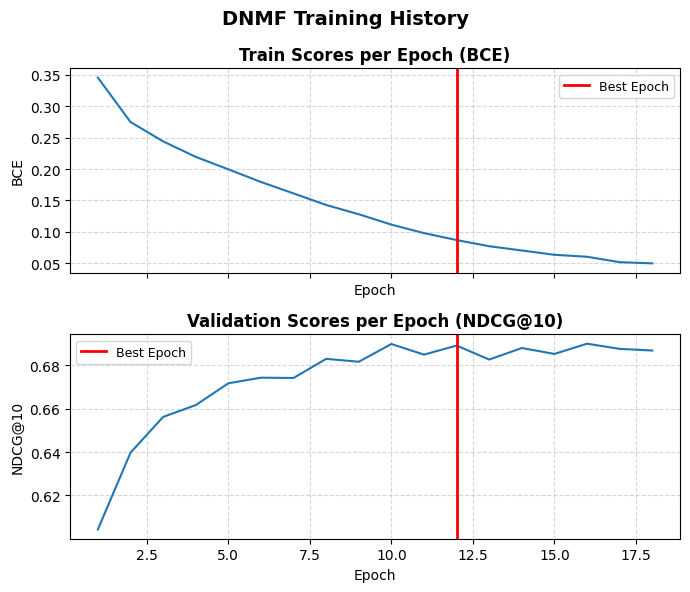

In [18]:
kwargs = dict(
    records=records,
    suptitle="DNMF Training History",
    trn="BCE",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [19]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [20]:
result, metrics_sheet = msr(dataloaders["tst"])

TST: 100%|██████████| 438/438 [00:05<00:00, 79.40it/s]


In [21]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.655996,0.169667,0.650243,0.683744,0.608195
1,10,0.713461,0.107400,0.718065,0.841796,0.626021
2,15,0.764104,0.080049,0.773865,0.913917,0.639542
3,20,0.801364,0.062202,0.811076,0.916143,0.648611
4,25,0.836526,0.051483,0.847119,0.917865,0.656789
5,50,0.952506,0.028528,0.966057,0.921581,0.680597


# Save

In [22]:
PATH = f'./checkpoints/{DATASET}/{MODEL_CLS}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)